In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prathameshkamblecd01","key":"f106c2b27a9ec8a5770c9fc3ed416f8e"}'}

You must authenticate before you can call the Kaggle API. The `kaggle.json` file has been uploaded, but it needs to be moved to the correct directory and have its permissions set.

In [ ]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the .kaggle directory
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file (read/write only for the owner)
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 90.5MB/s]



In [ ]:
!unzip sms-spam-collection-dataset.zip

Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


In [ ]:
import pandas as pd
df = pd.read_csv("/content/spam.csv", encoding='latin1')
df.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None


In [ ]:
print(df.describe())

          v1                      v2  \
count   5572                    5572   
unique     2                    5169   
top      ham  Sorry, I'll call later   
freq    4825                      30   

                                               Unnamed: 2  \
count                                                  50   
unique                                                 43   
top      bt not his girlfrnd... G o o d n i g h t . . .@"   
freq                                                    3   

                   Unnamed: 3 Unnamed: 4  
count                      12          6  
unique                     10          5  
top      MK17 92H. 450Ppw 16"    GNT:-)"  
freq                        2          2  


In [ ]:
print(df.isnull().sum())

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [ ]:
#Data cleaning
df=df[['v1','v2']]
df.columns=['label','message']
print(df.shape)

(5572, 2)


In [ ]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


In [ ]:
#check class Distribution
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


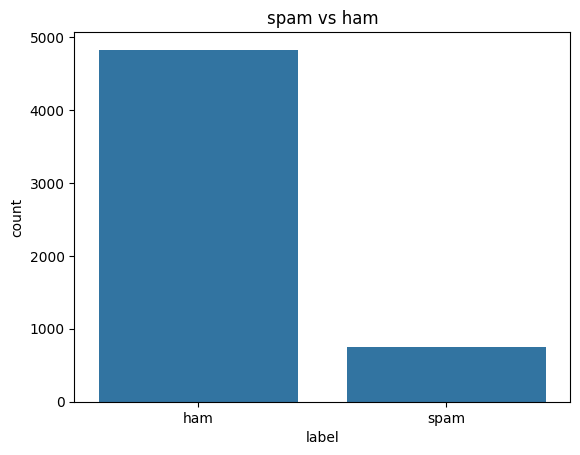

In [ ]:
#spam vs ham
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='label',data=df)
plt.title('spam vs ham')
plt.show()

In [ ]:
#message length analysis
df['length']=df['message'].apply(len)
print(df.head())

  label                                            message  length
0   ham  Go until jurong point, crazy.. Available only ...     111
1   ham                      Ok lar... Joking wif u oni...      29
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...     155
3   ham  U dun say so early hor... U c already then say...      49
4   ham  Nah I don't think he goes to usf, he lives aro...      61


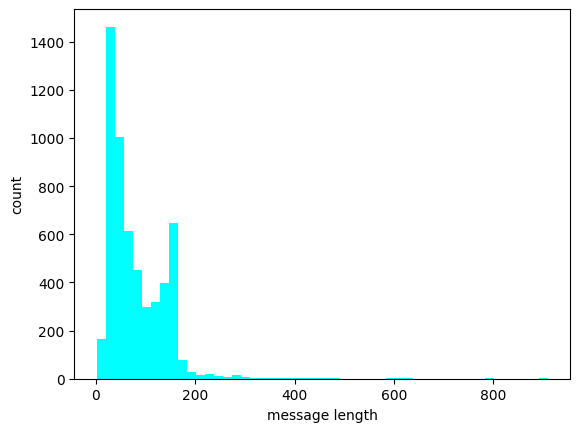

In [ ]:
#histogram
plt.hist(df['length'],bins=50,color='cyan')
plt.xlabel("message length")
plt.ylabel("count")
plt.show()

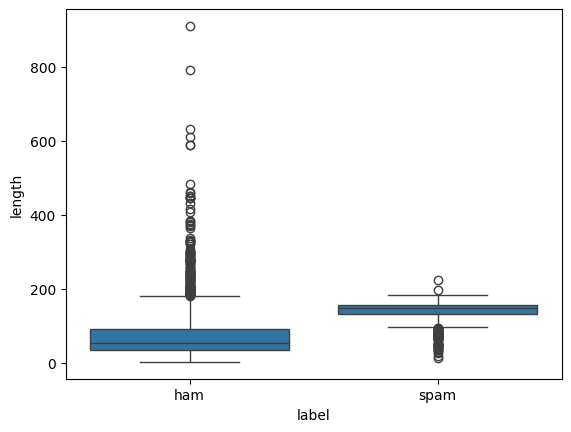

In [ ]:
sns.boxplot(x='label',y='length',data=df)
plt.show()

In [ ]:
#label encoding
df['label']=df['label'].map({'ham':0,'spam':1})
print(df.head())

   label                                            message  length
0      0  Go until jurong point, crazy.. Available only ...     111
1      0                      Ok lar... Joking wif u oni...      29
2      1  Free entry in 2 a wkly comp to win FA Cup fina...     155
3      0  U dun say so early hor... U c already then say...      49
4      0  Nah I don't think he goes to usf, he lives aro...      61


In [ ]:
#define feature and target
x=df['message']
y=df['label']
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)

(4457,)
(1115,)


In [ ]:
import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r'http\st','',text)
  text=re.sub(r'[^a-zA-Z]','',text)
  return text
df['clean_message']=df['message'].apply(clean_text)
x=df['clean_message']
print(df.head())

   label                                            message  length  \
0      0  Go until jurong point, crazy.. Available only ...     111   
1      0                      Ok lar... Joking wif u oni...      29   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...     155   
3      0  U dun say so early hor... U c already then say...      49   
4      0  Nah I don't think he goes to usf, he lives aro...      61   

                                       clean_message  
0  gountiljurongpointcrazyavailableonlyinbugisngr...  
1                                 oklarjokingwifuoni  
2  freeentryinawklycomptowinfacupfinaltktsstmayte...  
3                  udunsaysoearlyhorucalreadythensay  
4    nahidontthinkhegoestousfhelivesaroundherethough  


In [ ]:
#TF IDF vectorization
#convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
x_train_tfidf= tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)
print(x_train_tfidf.shape)

(4457, 7735)


In [ ]:
#train navie bayes
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train_tfidf,y_train)

MultinomialNB()

In [ ]:
#predictions, Accuracy
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test_tfidf)
accuracy=accuracy_score(y_test,y_test)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [ ]:
#Confusion metrics
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[965   0]
 [ 42 108]]


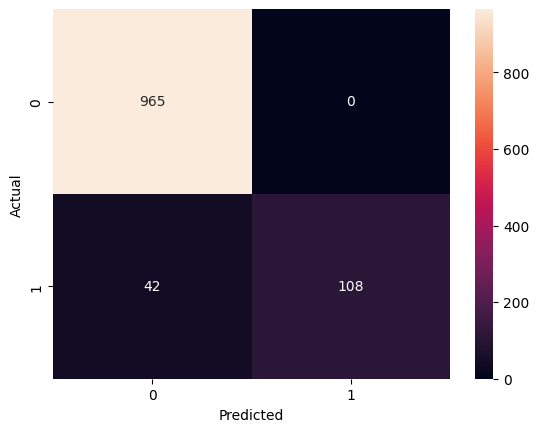

In [ ]:
#heatmap
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [ ]:
#find important spam words
feature_name=tfidf.get_feature_names_out()
spam_score=model.feature_log_prob_[1]
top_words=sorted(zip(spam_score,feature_name),reverse=True)[:20]
for score, word in top_words:
  print(word)

to
call
free
your
you
txt
now
or
for
mobile
claim
stop
the
from
have
ur
text
prize
is
on


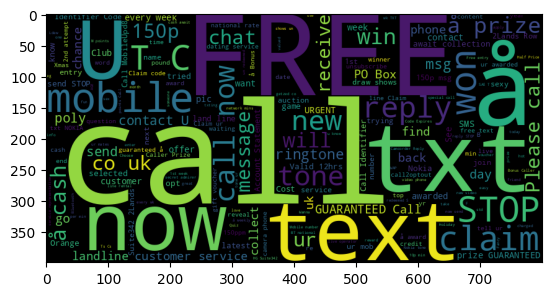

In [ ]:
#word cloud
from wordcloud import WordCloud
spam_text=''.join(df[df['label']==1]['message'])
wordcloud=WordCloud(width=800,height=400).generate(spam_text)
plt.imshow(wordcloud)
plt.show()

In [ ]:
#custom prediction
sms=["Congratulations! You won 50000 cash prize"]
vector= tfidf.transform(sms)
prediction=model.predict(vector)
print(prediction)

[1]


In [ ]:
#creat prediction function
def predict_sms(text):
  vector=tfidf.transform([text])
  result=model.predict(vector)[0]
  if result==1:
    return "spam"
  return "ham"
#test
print(predict_sms("Free Iphone waiting for you"))

ham


In [ ]:
import nltk
from nltk.corpus import stopwords # Moved this import statement here

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words=set(stopwords.words('english'))
def remove_stopwords(text):
  words=text.split() # Corrected: use text.split()
  words=[w for w in words if w not in stop_words] # Corrected: w in words
  return" ".join(words) # Corrected: join with space
df['clean_message'] = df['clean_message'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print('DataFrame after stopword removal:')
display(df[['message', 'clean_message']].head())

DataFrame after stopword removal:


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",gountiljurongpointcrazyavailableonlyinbugisngr...
1,Ok lar... Joking wif u oni...,oklarjokingwifuoni
2,Free entry in 2 a wkly comp to win FA Cup fina...,freeentryinawklycomptowinfacupfinaltktsstmayte...
3,U dun say so early hor... U c already then say...,udunsaysoearlyhorucalreadythensay
4,"Nah I don't think he goes to usf, he lives aro...",nahidontthinkhegoestousfhelivesaroundherethough


Now that the `clean_message` column has had stopwords removed, we need to update our feature variable `x` to reflect these changes. After updating `x`, we must re-perform the train-test split and re-apply TF-IDF vectorization to ensure our model is trained on the preprocessed data.

In [ ]:
# Update x with the clean_message column after stopword removal
x = df['clean_message']
y = df['label']

# Re-run train-test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print('Shapes after re-splitting data:')
print(f'x_train shape: {x_train.shape}')
print(f'x_test shape: {x_test.shape}')

Shapes after re-splitting data:
x_train shape: (4457,)
x_test shape: (1115,)


In [ ]:
# Re-initialize and re-fit TF-IDF vectorizer with the updated x_train
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print('Shapes after re-vectorization:')
print(f'x_train_tfidf shape: {x_train_tfidf.shape}')
print(f'x_test_tfidf shape: {x_test_tfidf.shape}')

Shapes after re-vectorization:
x_train_tfidf shape: (4457, 4131)
x_test_tfidf shape: (1115, 4131)


In [ ]:
# Re-train the Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train_tfidf, y_train)

print('Model re-trained successfully.')

Model re-trained successfully.


Accuracy after stopword removal: 0.8735

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       1.00      0.06      0.11       150

    accuracy                           0.87      1115
   macro avg       0.94      0.53      0.52      1115
weighted avg       0.89      0.87      0.82      1115



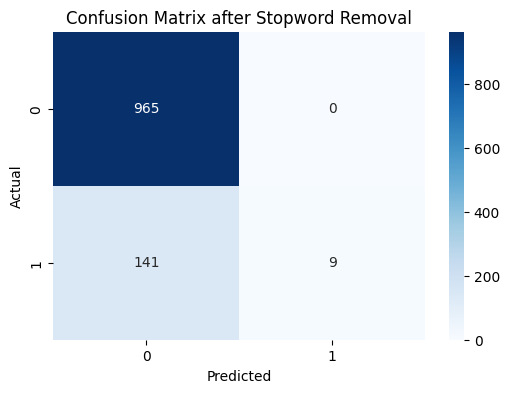

In [ ]:
# Make predictions and evaluate the model's performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(x_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy after stopword removal: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix after Stopword Removal')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#stemming
from nltk.stem import PorterStemmer
ps = PorterStemmer()
def stem_text(text):
  words=text.split()
  words=[ps.stem(word)for word in words]
  return"".join(words)
df['clean_message']=df['clean_message'].apply(stem_text)
df.head()

,label,message,length,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",111,gountiljurongpointcrazyavailableonlyinbugisngr...
1,0,Ok lar... Joking wif u oni...,29,oklarjokingwifuoni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,freeentryinawklycomptowinfacupfinaltktsstmayte...
3,0,U dun say so early hor... U c already then say...,49,udunsaysoearlyhorucalreadythensay
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nahidontthinkhegoestousfhelivesaroundherethough


In [ ]:
#train vs test accuracy
train_pred=model.predict(x_train_tfidf)
test_pred=model.predict(x_test_tfidf)
print("Train Accuracy:",accuracy_score(y_train,train_pred))
print("Train Accuracy:",accuracy_score(y_test,test_pred))


Train Accuracy: 0.8777204397576845
Train Accuracy: 0.873542600896861


In [ ]:
print("Precision Score")
from sklearn.metrics import precision_score
print(precision_score(y_test,y_pred))
print("Recall score")
from sklearn.metrics import recall_score
print(recall_score(y_test,y_pred))
print("F1 score")
from sklearn.metrics import f1_score
print(f1_score(y_test,y_pred))


Precision Score
1.0
Recall score
0.06
F1 score
0.11320754716981132


In [ ]:
#generate prediction csv
results=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
results.to_csv("Predictions_csv",index=False)

In [ ]:
#Error Analysis
misclassified=pd.DataFrame({'message':x_test,'Actual':y_test,'Predicted':y_pred})
misclassified=misclassified[misclassified['Actual']!=misclassified['Predicted']] # Corrected: '!' changed to '!='
print(misclassified.head())

                                                message  Actual  Predicted
1044  weknowsomeonewhoyouknowthatfanciesyoucalltofin...       1          0
812   congratulationsurawardedeitherofcdgiftvouchers...       1          0
1992  freetoneshopeyouenjoyedyournewcontenttextstopt...       1          0
2952  urgentyourmobilewasawardedabonuscallerprizeono...       1          0
5567  thisisthendtimewehavetriedcontactuuhavewonthep...       1          0


/tmp/ipykernel_9666/692181960.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


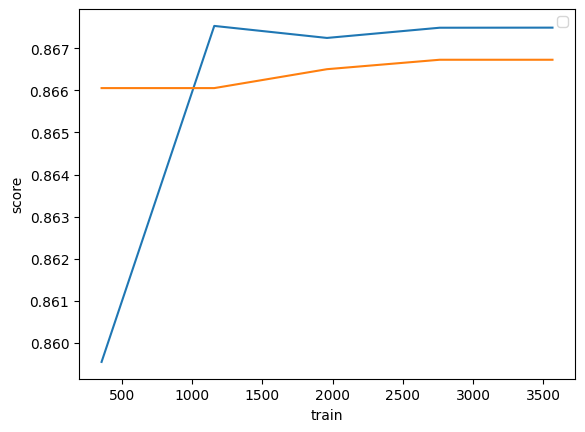

In [ ]:
#learning curve
from sklearn.model_selection import learning_curve
train_sizes,train_scores,test_scores=learning_curve(model,x_train_tfidf,y_train,cv=5)
plt.plot(train_sizes,train_scores.mean(axis=1))
plt.plot(train_sizes,test_scores.mean(axis=1))
plt.xlabel("train")
plt.ylabel("score")
plt.legend()
plt.show()

In [ ]:
#hyperparameter training
from sklearn.model_selection import GridSearchCV # Corrected: model_selection
params={'alpha':[0.1,0.5,4.0,2.0]}
grid=GridSearchCV(MultinomialNB(),params,cv=5)
grid.fit(x_train_tfidf,y_train)
print(grid.best_params_) # Corrected: best_params_

{'alpha': 0.1}


In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train_tfidf,y_train)
y_pred_lr=lr.predict(x_test_tfidf)
print("Accuracy:", accuracy_score(y_test,y_pred_lr))

Accuracy: 0.8699551569506726


In [ ]:
#support vector machine svm
from sklearn.svm import LinearSVC
svm=LinearSVC()
svm.fit(x_train_tfidf,y_train)
y_pred_svm=svm.predict(x_test_tfidf)
print("Accuracy:", accuracy_score(y_test,y_pred_svm))

Accuracy: 0.9139013452914798


In [ ]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100)
rf.fit(x_train_tfidf,y_train)
y_pred_rf=rf.predict(x_test_tfidf)
print("Accuracy:",accuracy_score(y_test,y_pred_rf))

Accuracy: 0.9139013452914798


In [ ]:
#Decesion tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_tfidf,y_train)
y_pred_dt=dt.predict(x_test_tfidf)
print("Accuracy:", accuracy_score(y_test,y_pred_dt))

Accuracy: 0.9139013452914798


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_tfidf,y_train)
y_pred_knn=knn.predict(x_test_tfidf)
print("Accuracy:", accuracy_score(y_test,y_pred_knn))

Accuracy: 0.873542600896861


In [ ]:
#XGBoost
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train_tfidf,y_train)
pred= xgb.predict(x_test_tfidf)
print(accuracy_score(y_test,pred))

0.8654708520179372


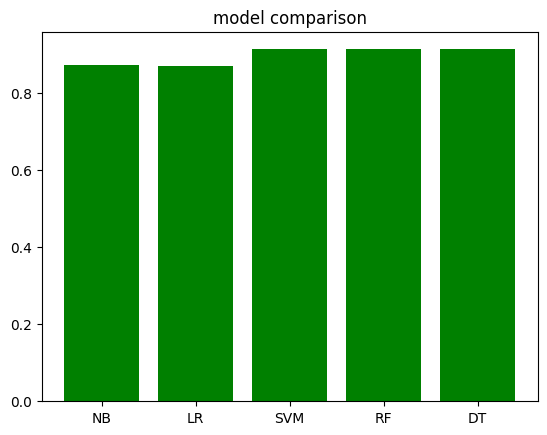

In [ ]:
#comparison table
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Assuming y_pred is for Naive Bayes from previous cells
nb_acc = accuracy_score(y_test, y_pred)
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)
rf_acc = accuracy_score(y_test, y_pred_rf)
dt_acc = accuracy_score(y_test, y_pred_dt)

models=['NB','LR','SVM','RF','DT']
scores=[nb_acc, lr_acc,svm_acc,rf_acc,dt_acc]
plt.bar(models,scores, color='g')
plt.title("model comparison")
plt.show()

In [ ]:
#save model
import pickle
pickle.dump(model,open("spam_model.pkl","wb"))
pickle.dump(tfidf,open("tfidf.pkl","wb"))
